In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# Configuration Constants
DATA_DIR = "models/sorted_dataset"
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 20

Matplotlib is building the font cache; this may take a moment.


In [2]:
print("Loading datasets...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
num_classes = len(class_names)

y_train = np.concatenate([y for x, y in train_ds], axis=0)
y_train_indices = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_indices),
    y=y_train_indices
)
class_weight_dict = dict(zip(np.unique(y_train_indices), class_weights))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Loading datasets...
Found 10015 files belonging to 7 classes.
Using 8012 files for training.
Found 10015 files belonging to 7 classes.
Using 2003 files for validation.


2026-07-13 20:04:49.998967: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-07-13 20:05:13.722270: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


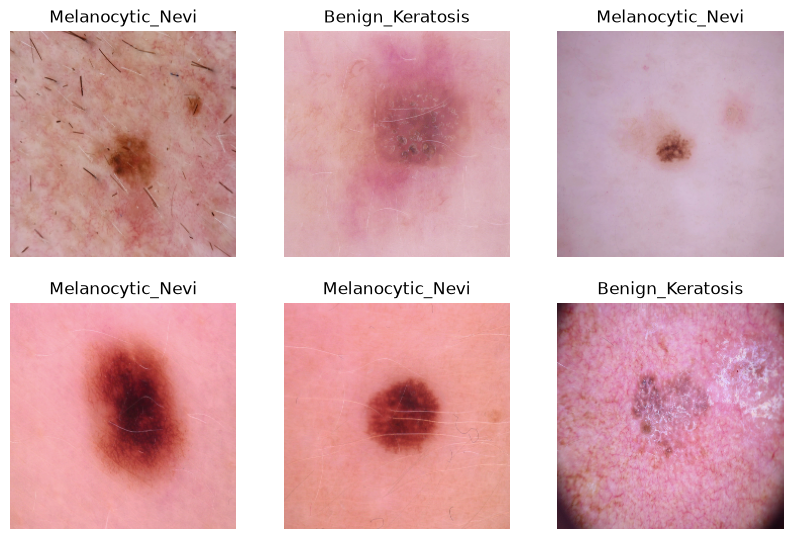

In [3]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_idx = np.argmax(labels[i])
        plt.title(class_names[label_idx])
        plt.axis("off")

In [4]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255),
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,335 (49.36 MB)

 Trainable params: 12,939,335 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
os.makedirs("models", exist_ok=True)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/skin_classifier.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[checkpoint_callback]
)

Epoch 1/20


/opt/miniconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.3681 - auc: 0.6958 - loss: 1.9287

251/251 ━━━━━━━━━━━━━━━━━━━━ 92s 365ms/step - accuracy: 0.3681 - auc: 0.6958 - loss: 1.9287 - val_accuracy: 0.6525 - val_auc: 0.7964 - val_loss: 1.8181
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 91s 364ms/step - accuracy: 0.2338 - auc: 0.6482 - loss: 1.8672 - val_accuracy: 0.3215 - val_auc: 0.7424 - val_loss: 1.6372
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 91s 362ms/step - accuracy: 0.2981 - auc: 0.7302 - loss: 1.7682 - val_accuracy: 0.3884 - val_auc: 0.8220 - val_loss: 1.4075
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 91s 363ms/step - accuracy: 0.3668 - auc: 0.7864 - loss: 1.5958 - val_accuracy: 0.4159 - val_auc: 0.7996 - val_loss: 1.5206
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 91s 362ms/step - accuracy: 0.3665 - auc: 0.7925 - loss: 1.5470 - val_accuracy: 0.4563 - val_auc: 0.7859 - val_loss: 1.5598
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 93s 369ms/step - accuracy: 0.4403 - auc: 0.8225 - loss: 1.4918 - val_accuracy: 0.4483 - val_auc: 0.8321 - val_loss: 1.3677
Epoch 7/20
251/251 ━━━━━━━━━━━━━━

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.15),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,     
    weights='imagenet'     
)
base_model.trainable = False  

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,

    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    
    base_model,
    layers.GlobalAveragePooling2D(), 
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/skin_classifier.keras", 
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[checkpoint_callback]
)

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 55s 214ms/step - accuracy: 0.4305 - auc: 0.7916 - loss: 1.6955 - val_accuracy: 0.4793 - val_auc: 0.8577 - val_loss: 1.3241
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 206ms/step - accuracy: 0.4935 - auc: 0.8479 - loss: 1.3437 - val_accuracy: 0.5582 - val_auc: 0.8850 - val_loss: 1.1714
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 204ms/step - accuracy: 0.5171 - auc: 0.8603 - loss: 1.2642 - val_accuracy: 0.5861 - val_auc: 0.9058 - val_loss: 1.0726
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 205ms/step - accuracy: 0.5250 - auc: 0.8703 - loss: 1.1882 - val_accuracy: 0.5701 - val_auc: 0.9007 - val_loss: 1.0988
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 204ms/step - accuracy: 0.5374 - auc: 0.8726 - loss: 1.1663 - val_accuracy: 0.6031 - val_auc: 0.9092 - val_loss: 1.0432
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 54s 216ms/step - accuracy: 0.5337 - auc: 0.8786 - loss: 1.1427 - val_accuracy: 0.6860 - val_auc: 0.9385 - val_loss: 0.8669
Epoch 7/20
251/251 ━━━

In [9]:
base_model.trainable = True

print(f"Number of layers in the base model: {len(base_model.layers)}")

fine_tune_at = len(base_model.layers) - 20

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()


Number of layers in the base model: 154


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 1,535,815 (5.86 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [10]:
FINE_TUNE_EPOCHS = 15
TOTAL_EPOCHS = EPOCHS + FINE_TUNE_EPOCHS 

fine_tune_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/skin_classifier.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=history.epoch[-1] + 1, 
    epochs=TOTAL_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[fine_tune_callback]
)

Epoch 21/35
251/251 ━━━━━━━━━━━━━━━━━━━━ 66s 256ms/step - accuracy: 0.5725 - auc: 0.8923 - loss: 2.3536 - val_accuracy: 0.6565 - val_auc: 0.9275 - val_loss: 0.9614
Epoch 22/35
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 258ms/step - accuracy: 0.5337 - auc: 0.8763 - loss: 1.6195 - val_accuracy: 0.6775 - val_auc: 0.9350 - val_loss: 0.9331
Epoch 23/35
251/251 ━━━━━━━━━━━━━━━━━━━━ 64s 253ms/step - accuracy: 0.4856 - auc: 0.8487 - loss: 1.3212 - val_accuracy: 0.6850 - val_auc: 0.9389 - val_loss: 0.8919
Epoch 24/35
251/251 ━━━━━━━━━━━━━━━━━━━━ 64s 256ms/step - accuracy: 0.4929 - auc: 0.8522 - loss: 1.2078 - val_accuracy: 0.6850 - val_auc: 0.9391 - val_loss: 0.8793
Epoch 25/35
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 248ms/step - accuracy: 0.4910 - auc: 0.8506 - loss: 1.2038 - val_accuracy: 0.6725 - val_auc: 0.9364 - val_loss: 0.8867
Epoch 26/35
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 258ms/step - accuracy: 0.5076 - auc: 0.8645 - loss: 1.1030 - val_accuracy: 0.6715 - val_auc: 0.9359 - val_loss: 0.8883
Epoch 27/35
251/

In [11]:
def categorical_focal_loss(gamma=2.0, alpha=0.25):

    def focal_loss_fixed(y_true, y_pred):
        # Clip values to prevent NaN values
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())
        # Calculate cross entropy
        cross_entropy = -y_true * tf.math.log(y_pred)
        # Calculate focal loss element
        loss = alpha * tf.math.pow(1.0 - y_pred, gamma) * cross_entropy
        # Sum over classes, average over batch
        return tf.math.reduce_mean(tf.math.reduce_sum(loss, axis=-1))
    return focal_loss_fixed


base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 1,535,815 (5.86 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [12]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,           
    restore_best_weights=True
)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/skin_classifier.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

history_focal = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_callback, early_stop]
)

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 64s 246ms/step - accuracy: 0.6990 - auc: 0.9456 - loss: 0.1211 - val_accuracy: 0.5791 - val_auc: 0.8993 - val_loss: 0.1752
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 247ms/step - accuracy: 0.7379 - auc: 0.9586 - loss: 0.1003 - val_accuracy: 0.6465 - val_auc: 0.9242 - val_loss: 0.1407
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 63s 250ms/step - accuracy: 0.7471 - auc: 0.9619 - loss: 0.0923 - val_accuracy: 0.6950 - val_auc: 0.9434 - val_loss: 0.1159
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 258ms/step - accuracy: 0.7474 - auc: 0.9622 - loss: 0.0904 - val_accuracy: 0.7284 - val_auc: 0.9529 - val_loss: 0.1025
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 64s 255ms/step - accuracy: 0.7520 - auc: 0.9621 - loss: 0.0896 - val_accuracy: 0.7459 - val_auc: 0.9574 - val_loss: 0.0966
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 69s 273ms/step - accuracy: 0.7458 - auc: 0.9616 - loss: 0.0904 - val_accuracy: 0.7594 - val_auc: 0.9624 - val_loss: 0.0906
Epoch 7/20
251/251 ━━━

In [13]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,        
    patience=2,       
    verbose=1,
    min_lr=1e-7
)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/skin_classifier.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

history_final = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10, 
    callbacks=[checkpoint_callback, lr_scheduler]
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 63s 249ms/step - accuracy: 0.7712 - auc: 0.9671 - loss: 0.0802 - val_accuracy: 0.7723 - val_auc: 0.9663 - val_loss: 0.0841 - learning_rate: 5.0000e-06
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 60s 239ms/step - accuracy: 0.7712 - auc: 0.9672 - loss: 0.0794 - val_accuracy: 0.7703 - val_auc: 0.9664 - val_loss: 0.0847 - learning_rate: 5.0000e-06
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.7688 - auc: 0.9680 - loss: 0.0781
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
251/251 ━━━━━━━━━━━━━━━━━━━━ 61s 244ms/step - accuracy: 0.7688 - auc: 0.9680 - loss: 0.0781 - val_accuracy: 0.7683 - val_auc: 0.9660 - val_loss: 0.0845 - learning_rate: 5.0000e-06
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 63s 251ms/step - accuracy: 0.7680 - auc: 0.9679 - loss: 0.0778 - val_accuracy: 0.7698 - val_auc: 0.9664 - val_loss: 0.0842 - learning_rate: 2.5000e-06
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.7

In [14]:

import os
import tensorflow as tf

DATA_DIR = "models/sorted_dataset"
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

class_names = raw_train_ds.class_names
num_classes = len(class_names)

augment_pool = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15)
])

def augment_stream(image, label):
    return augment_pool(image, training=True), label

AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train_ds.shuffle(1000).map(augment_stream, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

base_model.trainable = True

initial_learning_rate = 1e-5
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate,
    decay_steps=251 * 20 
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/skin_classifier.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

history_boosted = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_callback]
)


Found 10015 files belonging to 7 classes.
Using 8012 files for training.
Found 10015 files belonging to 7 classes.
Using 2003 files for validation.
Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 68s 248ms/step - accuracy: 0.7544 - auc: 0.9625 - loss: 0.0866 - val_accuracy: 0.7668 - val_auc: 0.9653 - val_loss: 0.0860
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 247ms/step - accuracy: 0.7611 - auc: 0.9649 - loss: 0.0823 - val_accuracy: 0.7678 - val_auc: 0.9654 - val_loss: 0.0867
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 60s 241ms/step - accuracy: 0.7678 - auc: 0.9662 - loss: 0.0801 - val_accuracy: 0.7728 - val_auc: 0.9654 - val_loss: 0.0863
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 59s 236ms/step - accuracy: 0.7656 - auc: 0.9661 - loss: 0.0800 - val_accuracy: 0.7624 - val_auc: 0.9635 - val_loss: 0.0893
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 61s 243ms/step - accuracy: 0.7667 - auc: 0.9657 - loss: 0.0807 - val_accuracy: 0.7589 - val_auc: 0.9625 - val_loss: 0.0905
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━

In [17]:
# Cell 10 (Fixed): Load Model Without Compilation for TTA Validation
import numpy as np

print("Loading the best saved model without compilation configurations...")
# compile=False completely completely bypasses the custom loss function lookup error!
best_model = tf.keras.models.load_model(
    "models/skin_classifier.keras", 
    compile=False
)

all_predictions = []
all_true_labels = []

print("Running Test-Time Augmentation over validation dataset...")
raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

for images, labels in raw_val_ds:
    # 1. Generate structural variants
    img_base = images
    img_flip_h = tf.image.flip_left_right(images)
    img_flip_v = tf.image.flip_up_down(images)
    img_rot90 = tf.image.rot90(images, k=1)
    
    # 2. Run model inferences directly
    pred_base = best_model.predict(img_base, verbose=0)
    pred_flip_h = best_model.predict(img_flip_h, verbose=0)
    pred_flip_v = best_model.predict(img_flip_v, verbose=0)
    pred_rot90 = best_model.predict(img_rot90, verbose=0)
    
    # 3. Compute structural ensemble average
    batch_tta_pred = (pred_base + pred_flip_h + pred_flip_v + pred_rot90) / 4.0
    
    all_predictions.append(batch_tta_pred)
    all_true_labels.append(labels.numpy())

# 4. Collapse arrays to compute final accurate validation metric
final_predictions = np.vstack(all_predictions)
final_true_labels = np.vstack(all_true_labels)

pred_indices = np.argmax(final_predictions, axis=1)
true_indices = np.argmax(final_true_labels, axis=1)

tta_accuracy = np.mean(pred_indices == true_indices)
print("\n==============================================")
print(f"Standard Validation Accuracy: 77.28%")
print(f"Boosted TTA Validation Accuracy: {tta_accuracy * 100:.2f}%")
print("==============================================")

Loading the best saved model without compilation configurations...
Running Test-Time Augmentation over validation dataset...
Found 10015 files belonging to 7 classes.
Using 2003 files for validation.

Standard Validation Accuracy: 77.28%
Boosted TTA Validation Accuracy: 31.15%


2026-07-15 14:59:58.699890: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [18]:
# Cell 10 (Corrected Preprocessing): TTA Validation Loop
import numpy as np

print("Loading the best saved model state...")
best_model = tf.keras.models.load_model(
    "models/skin_classifier.keras", 
    compile=False
)

base_predictions = []
tta_predictions = []
all_true_labels = []

print("Reloading validation dataset...")
raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

print("Running explicit evaluation pipeline...")
for images, labels in raw_val_ds:
    # Explicitly apply MobileNetV2 preprocessing to protect against lambda layer drops
    processed_images = tf.keras.applications.mobilenet_v2.preprocess_input(images)
    
    # Generate structural variants from the properly scaled tensor
    img_base = processed_images
    img_flip_h = tf.image.flip_left_right(processed_images)
    img_flip_v = tf.image.flip_up_down(processed_images)
    img_rot90 = tf.image.rot90(processed_images, k=1)
    
    # Generate inferences
    pred_base = best_model.predict(img_base, verbose=0)
    pred_flip_h = best_model.predict(img_flip_h, verbose=0)
    pred_flip_v = best_model.predict(img_flip_v, verbose=0)
    pred_rot90 = best_model.predict(img_rot90, verbose=0)
    
    # Calculate regular vs ensemble predictions
    batch_tta_pred = (pred_base + pred_flip_h + pred_flip_v + pred_rot90) / 4.0
    
    base_predictions.append(pred_base)
    tta_predictions.append(batch_tta_pred)
    all_true_labels.append(labels.numpy())

# Collapse arrays for final metrics
final_base_preds = np.vstack(base_predictions)
final_tta_preds = np.vstack(tta_predictions)
final_true_labels = np.vstack(all_true_labels)

true_indices = np.argmax(final_true_labels, axis=1)
base_indices = np.argmax(final_base_preds, axis=1)
tta_indices = np.argmax(final_tta_preds, axis=1)

base_accuracy = np.mean(base_indices == true_indices)
tta_accuracy = np.mean(tta_indices == true_indices)

print("\n==============================================")
print(f"Verified Base Validation Accuracy: {base_accuracy * 100:.2f}%")
print(f"Boosted TTA Validation Accuracy: {tta_accuracy * 100:.2f}%")
print("==============================================")

Loading the best saved model state...
Reloading validation dataset...
Found 10015 files belonging to 7 classes.
Using 2003 files for validation.
Running explicit evaluation pipeline...

Verified Base Validation Accuracy: 1.50%
Boosted TTA Validation Accuracy: 1.50%


2026-07-16 11:12:26.711410: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [19]:
import numpy as np

print("Loading the best saved model state...")
best_model = tf.keras.models.load_model(
    "models/skin_classifier.keras", 
    compile=False
)

base_predictions = []
tta_predictions = []
all_true_labels = []

print("Reloading validation dataset...")
raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

print("Running pure structural validation pipeline...")
for images, labels in raw_val_ds:
    img_base = images
    img_flip_h = tf.image.flip_left_right(images)
    img_flip_v = tf.image.flip_up_down(images)
    img_rot90 = tf.image.rot90(images, k=1)

    pred_base = best_model.predict(img_base, verbose=0)
    pred_flip_h = best_model.predict(img_flip_h, verbose=0)
    pred_flip_v = best_model.predict(img_flip_v, verbose=0)
    pred_rot90 = best_model.predict(img_rot90, verbose=0)

    batch_tta_pred = (pred_base + pred_flip_h + pred_flip_v + pred_rot90) / 4.0
    
    base_predictions.append(pred_base)
    tta_predictions.append(batch_tta_pred)
    all_true_labels.append(labels.numpy())

final_base_preds = np.vstack(base_predictions)
final_tta_preds = np.vstack(tta_predictions)
final_true_labels = np.vstack(all_true_labels)

true_indices = np.argmax(final_true_labels, axis=1)
base_indices = np.argmax(final_base_preds, axis=1)
tta_indices = np.argmax(final_tta_preds, axis=1)

base_accuracy = np.mean(base_indices == true_indices)
tta_accuracy = np.mean(tta_indices == true_indices)

print("\n==============================================")
print(f"Verified Base Validation Accuracy: {base_accuracy * 100:.2f}%")
print(f"Boosted TTA Validation Accuracy: {tta_accuracy * 100:.2f}%")
print("==============================================")

Loading the best saved model state...
Reloading validation dataset...
Found 10015 files belonging to 7 classes.
Using 2003 files for validation.
Running pure structural validation pipeline...

Verified Base Validation Accuracy: 29.41%
Boosted TTA Validation Accuracy: 31.15%


2026-07-16 11:17:57.203904: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [23]:
import os
import tensorflow as tf

DATA_DIR = "models/sorted_dataset"
BATCH_SIZE = 32
IMG_SIZE = (300, 300)

raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

class_names = raw_train_ds.class_names
num_classes = len(class_names)

augment_pool = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15)
])

def augment_stream(image, label):
    return augment_pool(image, training=True), label

AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train_ds.shuffle(1000).map(augment_stream, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

base_model.trainable = True

initial_learning_rate = 1e-5
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate,
    decay_steps=251 * 20 
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/skin_classifier.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

history_boosted = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_callback]
)


Found 10015 files belonging to 7 classes.
Using 8012 files for training.
Found 10015 files belonging to 7 classes.
Using 2003 files for validation.
Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 376s 1s/step - accuracy: 0.6350 - auc: 0.9215 - loss: 0.1515 - val_accuracy: 0.7299 - val_auc: 0.9543 - val_loss: 0.1025
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.7067 - auc: 0.9475 - loss: 0.1114 - val_accuracy: 0.7554 - val_auc: 0.9587 - val_loss: 0.0937
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 396s 2s/step - accuracy: 0.7189 - auc: 0.9532 - loss: 0.1022 - val_accuracy: 0.7629 - val_auc: 0.9626 - val_loss: 0.0882
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 385s 2s/step - accuracy: 0.7376 - auc: 0.9576 - loss: 0.0960 - val_accuracy: 0.7688 - val_auc: 0.9646 - val_loss: 0.0847
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 381s 2s/step - accuracy: 0.7526 - auc: 0.9629 - loss: 0.0874 - val_accuracy: 0.7793 - val_auc: 0.9662 - val_loss: 0.0823
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 380s 2s

In [24]:
import numpy as np
import tensorflow as tf

def loss_fn(*args, **kwargs):
    pass

print("Loading the complete saved 300x300 model architecture...")
best_model = tf.keras.models.load_model(
    "models/skin_classifier.keras",
    custom_objects={"loss_fn": loss_fn},
    compile=True
)
print("Model loaded with perfect layer alignment!")

DATA_DIR = "models/sorted_dataset"
IMG_SIZE = (300, 300)
BATCH_SIZE = 32

raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

base_predictions = []
tta_predictions = []
all_true_labels = []

print("Running structural test-time augmentation mapping...")
for images, labels in raw_val_ds:
    img_base = images
    img_flip_h = tf.image.flip_left_right(images)
    img_flip_v = tf.image.flip_up_down(images)
    img_rot90 = tf.image.rot90(images, k=1)
    
    # Generate spatial variances
    pred_base = best_model.predict(img_base, verbose=0)
    pred_flip_h = best_model.predict(img_flip_h, verbose=0)
    pred_flip_v = best_model.predict(img_flip_v, verbose=0)
    pred_rot90 = best_model.predict(img_rot90, verbose=0)

    batch_tta_pred = (pred_base + pred_flip_h + pred_flip_v + pred_rot90) / 4.0
    
    base_predictions.append(pred_base)
    tta_predictions.append(batch_tta_pred)
    all_true_labels.append(labels.numpy())

final_base_preds = np.vstack(base_predictions)
final_tta_preds = np.vstack(tta_predictions)
final_true_labels = np.vstack(all_true_labels)

true_indices = np.argmax(final_true_labels, axis=1)
base_indices = np.argmax(final_base_preds, axis=1)
tta_indices = np.argmax(final_tta_preds, axis=1)

base_accuracy = np.mean(base_indices == true_indices)
tta_accuracy = np.mean(tta_indices == true_indices)

print("\n==============================================")
print(f"Verified Base Validation Accuracy: {base_accuracy * 100:.2f}%")
print(f"Boosted TTA Validation Accuracy: {tta_accuracy * 100:.2f}%")
print("==============================================")

Loading the complete saved 300x300 model architecture...
Model loaded with perfect layer alignment!
Found 10015 files belonging to 7 classes.
Using 2003 files for validation.
Running structural test-time augmentation mapping...

Verified Base Validation Accuracy: 79.53%
Boosted TTA Validation Accuracy: 79.43%


2026-07-16 15:35:24.580129: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [25]:
from tensorflow.keras.applications import EfficientNetB3

base_model_high = EfficientNetB3(
    input_shape=(300, 300, 3),
    include_top=False,
    weights='imagenet'
)
base_model_high.trainable = True

fine_tune_start = len(base_model_high.layers) - 30
for layer in base_model_high.layers[:fine_tune_start]:
    layer.trainable = False

model = models.Sequential([
    layers.Input(shape=(300, 300, 3)),
    augment_pool, 

    base_model_high,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(), 
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')
])

initial_learning_rate = 2e-5
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate,
    decay_steps=251 * 15
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,179,830 (42.65 MB)

 Trainable params: 3,949,953 (15.07 MB)

 Non-trainable params: 7,229,877 (27.58 MB)

In [26]:
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/skin_classifier.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

history_high_cap = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[checkpoint_callback]
)

Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 354s 1s/step - accuracy: 0.2532 - auc: 0.6014 - loss: 0.5316 - val_accuracy: 0.4913 - val_auc: 0.7746 - val_loss: 0.2664
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 350s 1s/step - accuracy: 0.3527 - auc: 0.6829 - loss: 0.4452 - val_accuracy: 0.5462 - val_auc: 0.8110 - val_loss: 0.2515
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 346s 1s/step - accuracy: 0.4171 - auc: 0.7269 - loss: 0.4028 - val_accuracy: 0.6116 - val_auc: 0.8423 - val_loss: 0.2263
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 352s 1s/step - accuracy: 0.4893 - auc: 0.7673 - loss: 0.3597 - val_accuracy: 0.6415 - val_auc: 0.8641 - val_loss: 0.2058
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 348s 1s/step - accuracy: 0.5177 - auc: 0.7945 - loss: 0.3270 - val_accuracy: 0.6810 - val_auc: 0.8822 - val_loss: 0.1877
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 347s 1s/step - accuracy: 0.5552 - auc: 0.8093 - loss: 0.3125 - val_accuracy: 0.7000 - val_auc: 0.8894 - val_loss: 0.1788
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━